# Exploratory Data Analysis — AmbiStory Dataset
## SemEval-2026 Task 5: Rating Plausibility of Word Senses in Ambiguous Sentences through Narrative Understanding

This notebook provides a comprehensive EDA of the AmbiStory dataset used for the task. The dataset contains short 5-sentence stories with a target homonym, and human plausibility ratings (1–5) for two possible word senses.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

SEED = 42
np.random.seed(SEED)

## 1. Dataset Loading and Overview

In [2]:
# Load train and validation sets
# NOTE: test set is in data/locked_test/ and is NOT used in this notebook.

def load_dataset(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data, orient="index")
    return df

train_df = load_dataset("data/train/train.json")
val_df = load_dataset("data/validation/dev.json")

print(f"Training set:   {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Total:          {len(train_df) + len(val_df)} samples")
print(f"\nTrain/Val ratio: {len(train_df)/(len(train_df)+len(val_df))*100:.1f}% / {len(val_df)/(len(train_df)+len(val_df))*100:.1f}%")

Training set:   2280 samples
Validation set: 588 samples
Total:          2868 samples

Train/Val ratio: 79.5% / 20.5%


In [3]:
# Column overview
print("Columns and data types:\n")
print(train_df.dtypes)
print(f"\nShape: {train_df.shape}")
print(f"\nNull counts:\n{train_df.isnull().sum()}")

Columns and data types:

homonym                 str
judged_meaning          str
precontext              str
sentence                str
ending                  str
choices              object
average             float64
stdev               float64
nonsensical          object
sample_id               str
example_sentence        str
dtype: object

Shape: (2280, 11)

Null counts:
homonym             0
judged_meaning      0
precontext          0
sentence            0
ending              0
choices             0
average             0
stdev               0
nonsensical         0
sample_id           0
example_sentence    0
dtype: int64


In [4]:
# Preview first 3 samples
train_df.head(3)

,homonym,judged_meaning,precontext,sentence,ending,choices,average,stdev,nonsensical,sample_id,example_sentence
0,potential,the difference in electrical charge between tw...,The old machine hummed in the corner of the wo...,The potential couldn't be measured.,She collected a battery reader and looked on e...,"[4, 5, 2, 3, 1]",3.0,1.581139,"[False, False, False, False, False]",1843,The circuit has a high potential difference.
1,potential,the inherent capacity for coming into being,The old machine hummed in the corner of the wo...,The potential couldn't be measured.,She collected a battery reader and looked on e...,"[5, 3, 4, 4, 3]",3.8,0.836660,"[False, False, False, False, False]",1844,The project has great potential for success.
2,potential,the difference in electrical charge between tw...,The old machine hummed in the corner of the wo...,The potential couldn't be measured.,The machine could make such wonderful clothing...,"[2, 1, 4, 3, 1]",2.2,1.303840,"[False, False, False, False, False]",1845,The circuit has a high potential difference.


## 2. Example Stories and Target Homonyms

Each sample consists of a 5-sentence story (precontext + sentence + ending) containing a target **homonym**. Two senses of the homonym are rated for plausibility.

In [5]:
# Display 2 example stories with their sense definitions and ratings
for idx in [0, 1]:
    row = train_df.iloc[idx]
    full_story = f"{row['precontext']} {row['sentence']} {row['ending']}"
    print(f"--- Example {idx+1} ---")
    print(f"Homonym:          {row['homonym']}")
    print(f"Story:            {full_story}")
    print(f"Judged Meaning:   {row['judged_meaning']}")
    print(f"Example Sentence: {row['example_sentence']}")
    print(f"Human Ratings:    {row['choices']}")
    print(f"Average Rating:   {row['average']:.2f} (std: {row['stdev']:.2f})")
    print(f"Nonsensical:      {row['nonsensical']}")
    print()

--- Example 1 ---
Homonym:          potential
Story:            The old machine hummed in the corner of the workshop. Clara examined its dusty dials with a furrowed brow. She wondered if it could be brought back to life. The potential couldn't be measured. She collected a battery reader and looked on earnestly, willing some life back into the old machine.
Judged Meaning:   the difference in electrical charge between two points in a circuit expressed in volts
Example Sentence: The circuit has a high potential difference.
Human Ratings:    [4, 5, 2, 3, 1]
Average Rating:   3.00 (std: 1.58)
Nonsensical:      [False, False, False, False, False]

--- Example 2 ---
Homonym:          potential
Story:            The old machine hummed in the corner of the workshop. Clara examined its dusty dials with a furrowed brow. She wondered if it could be brought back to life. The potential couldn't be measured. She collected a battery reader and looked on earnestly, willing some life back into the old m

## 3. Target Variable Distribution — Plausibility Ratings

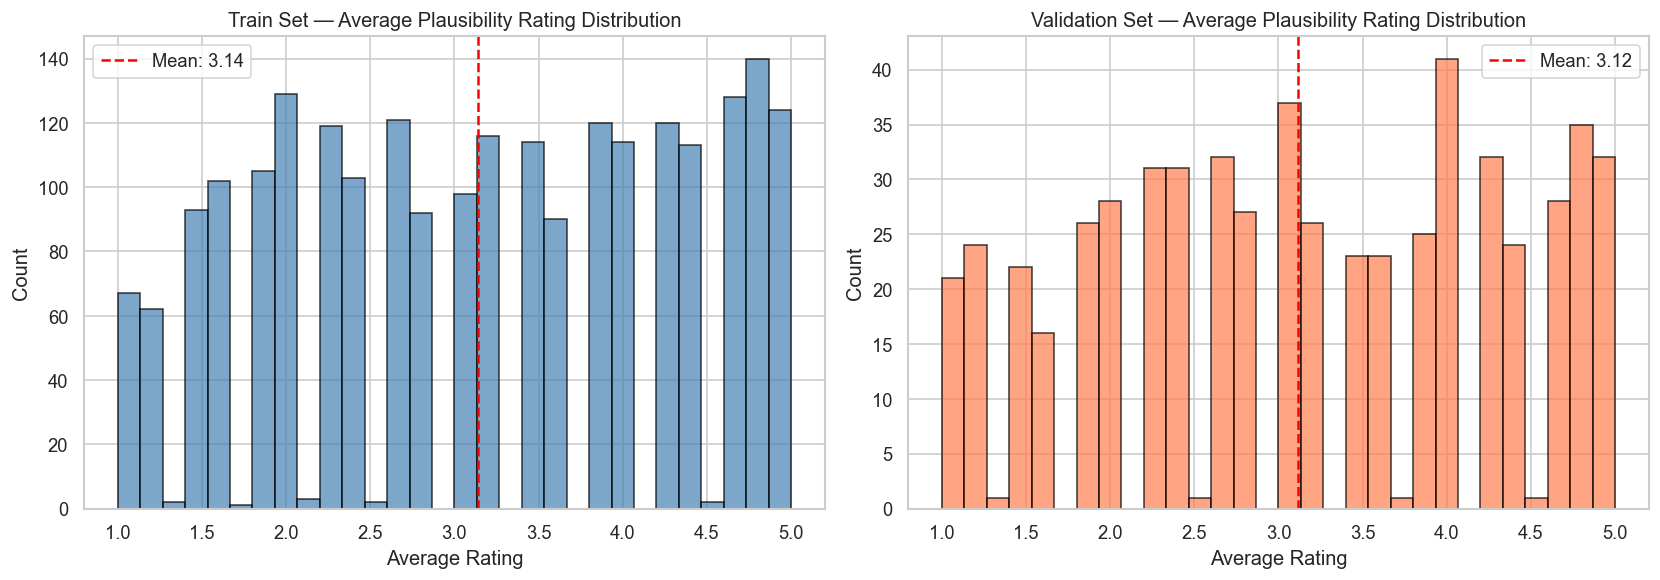

Train — Mean: 3.140, Median: 3.200, Std: 1.187
Val   — Mean: 3.118, Median: 3.000, Std: 1.186


In [6]:
# Distribution of average plausibility ratings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].hist(train_df["average"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_title("Train Set — Average Plausibility Rating Distribution")
axes[0].set_xlabel("Average Rating")
axes[0].set_ylabel("Count")
axes[0].axvline(train_df["average"].mean(), color="red", linestyle="--", label=f"Mean: {train_df['average'].mean():.2f}")
axes[0].legend()

# Validation set
axes[1].hist(val_df["average"], bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_title("Validation Set — Average Plausibility Rating Distribution")
axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("Count")
axes[1].axvline(val_df["average"].mean(), color="red", linestyle="--", label=f"Mean: {val_df['average'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Train — Mean: {train_df['average'].mean():.3f}, Median: {train_df['average'].median():.3f}, Std: {train_df['average'].std():.3f}")
print(f"Val   — Mean: {val_df['average'].mean():.3f}, Median: {val_df['average'].median():.3f}, Std: {val_df['average'].std():.3f}")

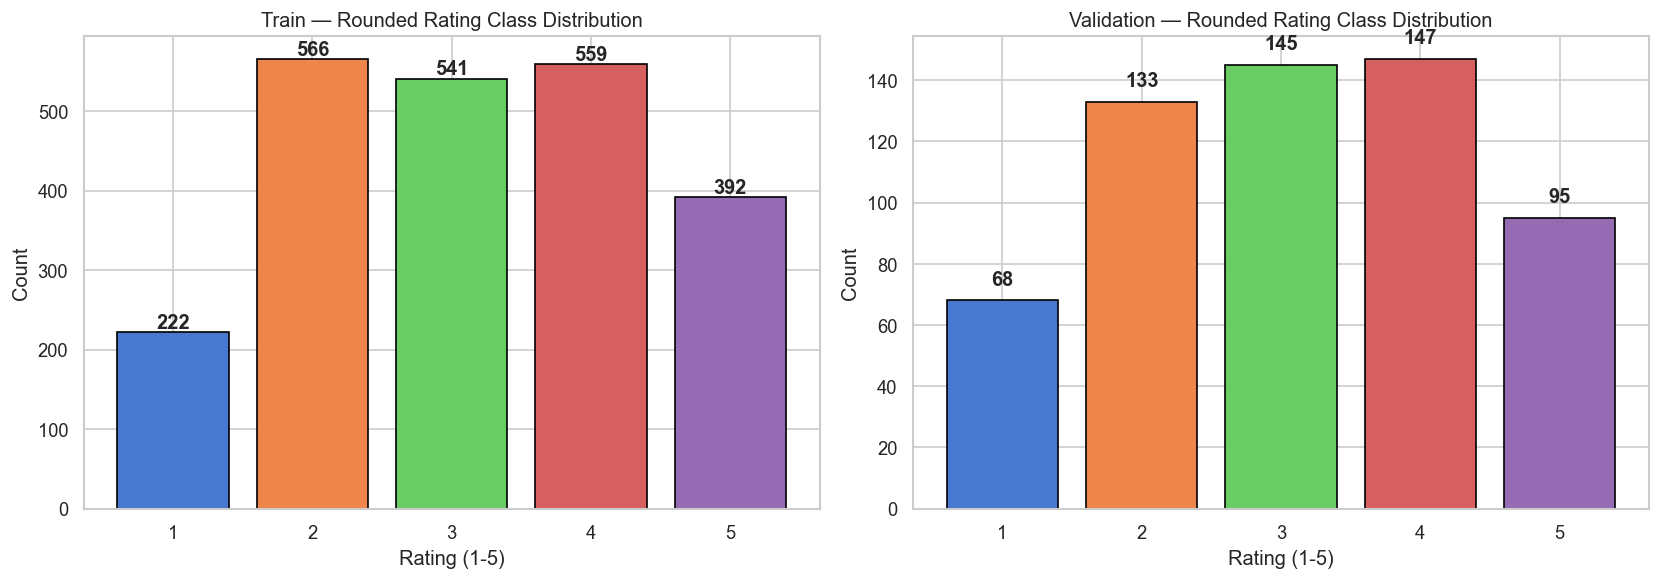

In [7]:
# Rounded rating distribution (since the task can also be viewed as classification 1-5)
train_df["rounded_rating"] = train_df["average"].round().astype(int).clip(1, 5)
val_df["rounded_rating"] = val_df["average"].round().astype(int).clip(1, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [(axes[0], train_df, "Train"), (axes[1], val_df, "Validation")]:
    counts = df["rounded_rating"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=sns.color_palette("muted"), edgecolor="black")
    ax.set_title(f"{title} — Rounded Rating Class Distribution")
    ax.set_xlabel("Rating (1-5)")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

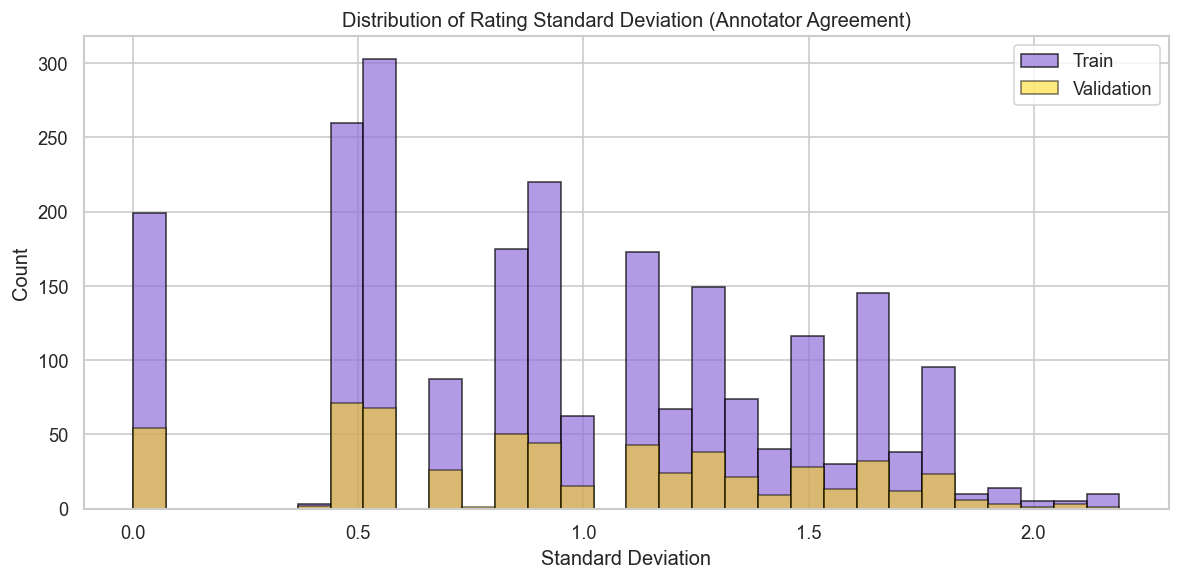

Train stdev — Mean: 0.948, Median: 0.894
Val   stdev — Mean: 0.949, Median: 0.894


In [8]:
# Standard deviation distribution — measures annotator agreement
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df["stdev"], bins=30, edgecolor="black", alpha=0.7, color="mediumpurple", label="Train")
ax.hist(val_df["stdev"], bins=30, edgecolor="black", alpha=0.5, color="gold", label="Validation")
ax.set_title("Distribution of Rating Standard Deviation (Annotator Agreement)")
ax.set_xlabel("Standard Deviation")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train stdev — Mean: {train_df['stdev'].mean():.3f}, Median: {train_df['stdev'].median():.3f}")
print(f"Val   stdev — Mean: {val_df['stdev'].mean():.3f}, Median: {val_df['stdev'].median():.3f}")

## 4. Homonym Analysis

In [9]:
# Number of unique homonyms
print(f"Unique homonyms in train: {train_df['homonym'].nunique()}")
print(f"Unique homonyms in val:   {val_df['homonym'].nunique()}")

# Overlap
train_homonyms = set(train_df["homonym"].unique())
val_homonyms = set(val_df["homonym"].unique())
overlap = train_homonyms & val_homonyms
only_train = train_homonyms - val_homonyms
only_val = val_homonyms - train_homonyms
print(f"\nOverlap: {len(overlap)} homonyms appear in both sets")
print(f"Only in train: {len(only_train)}")
print(f"Only in val:   {len(only_val)}")

Unique homonyms in train: 220
Unique homonyms in val:   55

Overlap: 0 homonyms appear in both sets
Only in train: 220
Only in val:   55


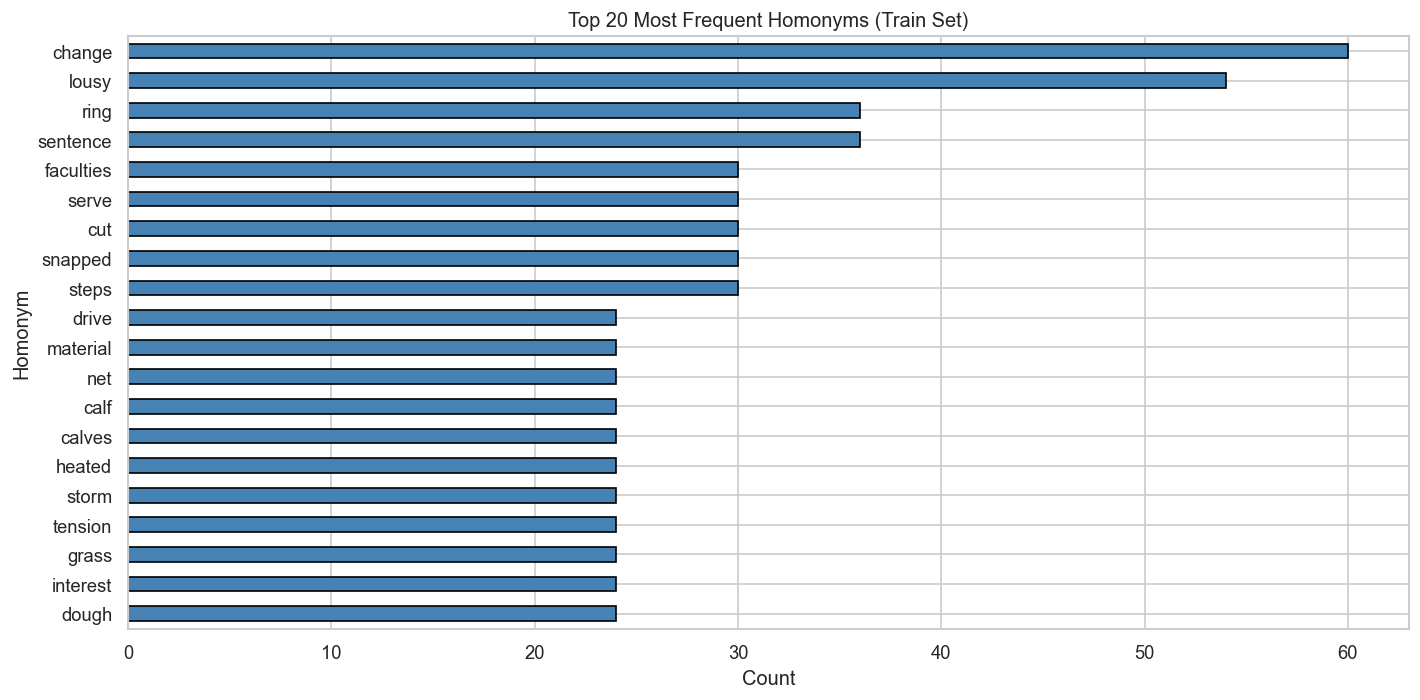


Samples per homonym — Mean: 10.4, Min: 6, Max: 60


In [10]:
# Top 20 most frequent homonyms in train set
top_homonyms = train_df["homonym"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_homonyms.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 20 Most Frequent Homonyms (Train Set)")
ax.set_xlabel("Count")
ax.set_ylabel("Homonym")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nSamples per homonym — Mean: {train_df['homonym'].value_counts().mean():.1f}, "
      f"Min: {train_df['homonym'].value_counts().min()}, "
      f"Max: {train_df['homonym'].value_counts().max()}")

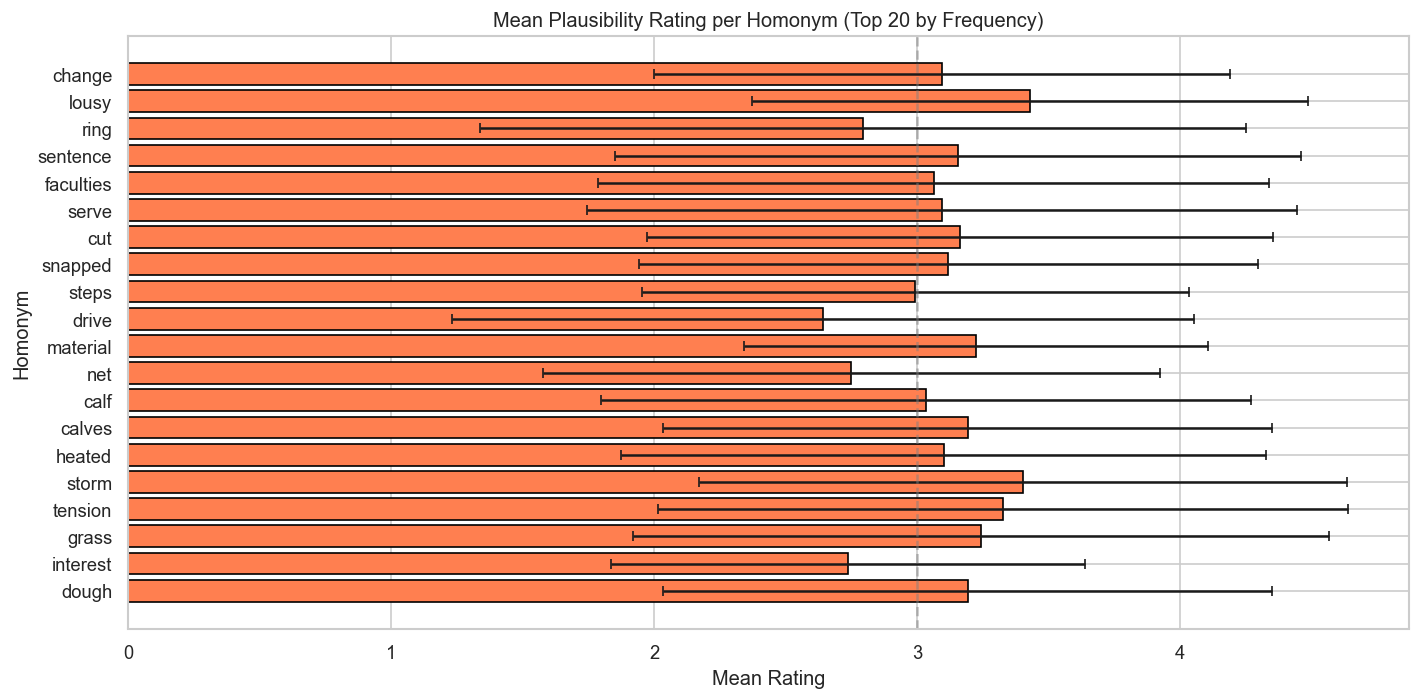

In [11]:
# Average plausibility rating per homonym (top 20 by frequency)
top20_names = top_homonyms.index.tolist()
homonym_avg = train_df[train_df["homonym"].isin(top20_names)].groupby("homonym")["average"].agg(["mean", "std"]).loc[top20_names]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(homonym_avg.index, homonym_avg["mean"], xerr=homonym_avg["std"], 
        color="coral", edgecolor="black", capsize=3)
ax.set_title("Mean Plausibility Rating per Homonym (Top 20 by Frequency)")
ax.set_xlabel("Mean Rating")
ax.set_ylabel("Homonym")
ax.invert_yaxis()
ax.axvline(x=3.0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Sense Pair Analysis (Sense 1 vs Sense 2)

Each homonym in a given story context has two senses rated. We pair entries by `sample_id` to compare how the two senses relate to each other.

In [12]:
# Pair entries by story context (same homonym + precontext + sentence + ending = same story, 2 senses)
train_df["story_key"] = (train_df["homonym"] + "|||" + train_df["precontext"] + "|||" 
                         + train_df["sentence"] + "|||" + train_df["ending"])

group_sizes = train_df.groupby("story_key").size().value_counts().sort_index()
print(f"Entries per story context:\n{group_sizes}")
print(f"\nTotal unique stories: {train_df['story_key'].nunique()}")

# Create paired dataframe
paired_data = []
for key, group in train_df.groupby("story_key"):
    if len(group) == 2:
        r1, r2 = group.iloc[0], group.iloc[1]
        paired_data.append({
            "homonym": r1["homonym"],
            "sense1_meaning": r1["judged_meaning"],
            "sense2_meaning": r2["judged_meaning"],
            "sense1_avg": r1["average"],
            "sense2_avg": r2["average"],
            "sense1_std": r1["stdev"],
            "sense2_std": r2["stdev"],
        })

paired_df = pd.DataFrame(paired_data)
print(f"\nPaired stories: {len(paired_df)}")

Entries per story context:
2    1140
Name: count, dtype: int64

Total unique stories: 1140



Paired stories: 1140


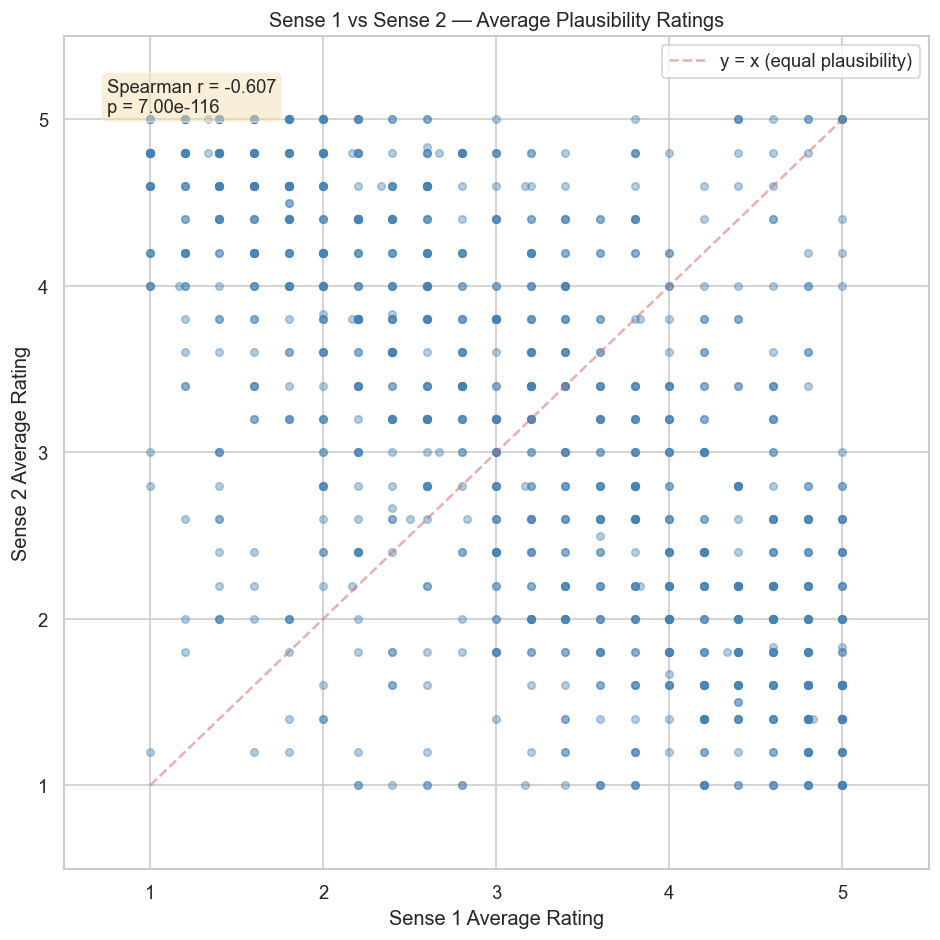

In [13]:
# Scatter plot: Sense 1 vs Sense 2 average ratings
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(paired_df["sense1_avg"], paired_df["sense2_avg"], alpha=0.4, s=20, color="steelblue")
ax.plot([1, 5], [1, 5], "r--", alpha=0.5, label="y = x (equal plausibility)")
ax.set_title("Sense 1 vs Sense 2 — Average Plausibility Ratings")
ax.set_xlabel("Sense 1 Average Rating")
ax.set_ylabel("Sense 2 Average Rating")
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.legend()

# Correlation
corr, pval = stats.spearmanr(paired_df["sense1_avg"], paired_df["sense2_avg"])
ax.text(0.05, 0.95, f"Spearman r = {corr:.3f}\np = {pval:.2e}", 
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

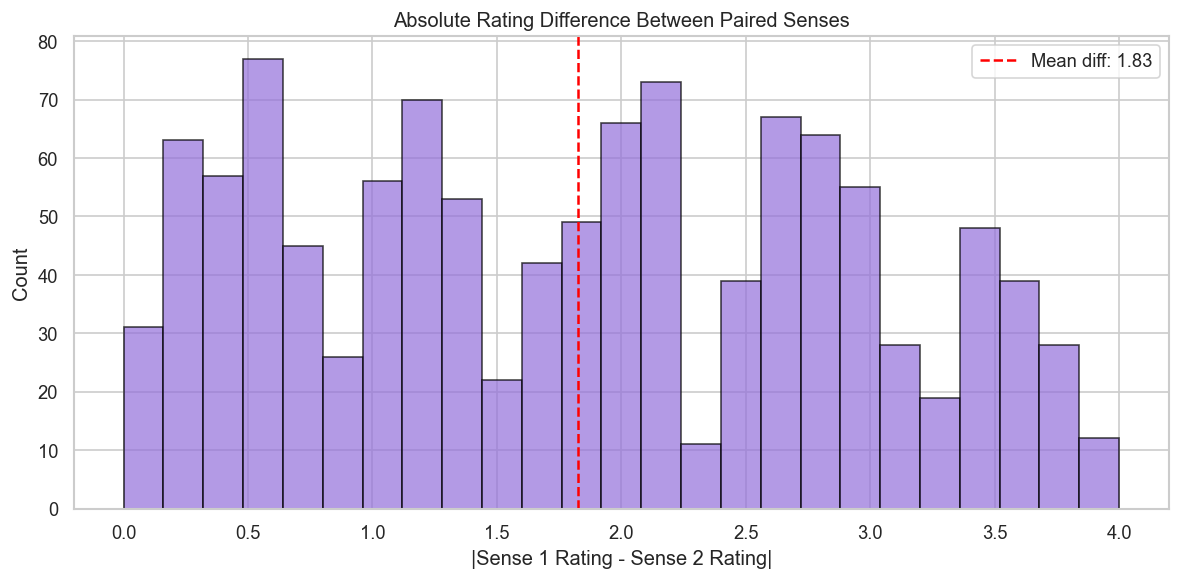

Mean absolute difference: 1.827
Pairs with diff < 1.0:   301 (26.4%)
Pairs with diff >= 2.0:  531 (46.6%)


In [14]:
# Rating difference between paired senses
paired_df["rating_diff"] = (paired_df["sense1_avg"] - paired_df["sense2_avg"]).abs()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(paired_df["rating_diff"], bins=25, edgecolor="black", alpha=0.7, color="mediumpurple")
ax.set_title("Absolute Rating Difference Between Paired Senses")
ax.set_xlabel("|Sense 1 Rating - Sense 2 Rating|")
ax.set_ylabel("Count")
ax.axvline(paired_df["rating_diff"].mean(), color="red", linestyle="--", 
           label=f"Mean diff: {paired_df['rating_diff'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean absolute difference: {paired_df['rating_diff'].mean():.3f}")
print(f"Pairs with diff < 1.0:   {(paired_df['rating_diff'] < 1.0).sum()} ({(paired_df['rating_diff'] < 1.0).mean()*100:.1f}%)")
print(f"Pairs with diff >= 2.0:  {(paired_df['rating_diff'] >= 2.0).sum()} ({(paired_df['rating_diff'] >= 2.0).mean()*100:.1f}%)")

## 6. Text Length Statistics

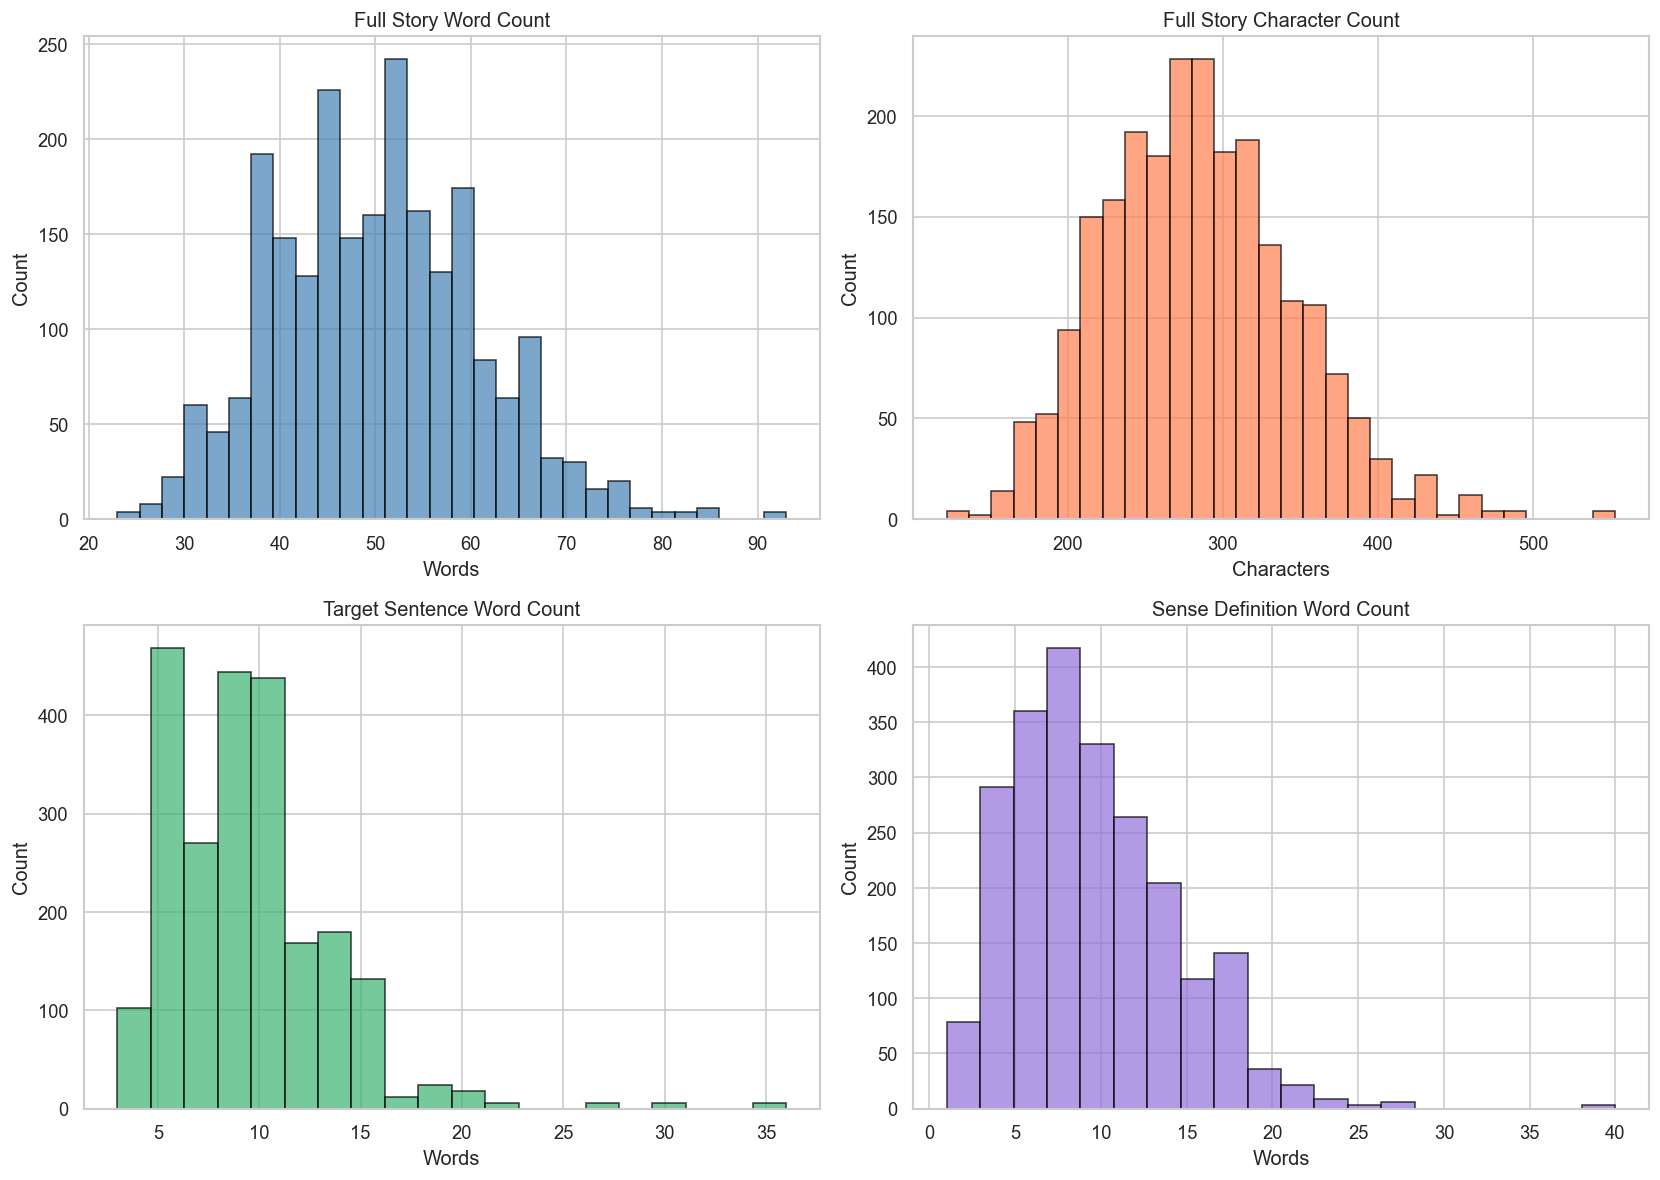

Story word count stats:
count    2280.000000
mean       49.986842
std        10.725536
min        23.000000
25%        42.000000
50%        50.000000
75%        57.000000
max        93.000000

Target sentence word count stats:
count    2280.000000
mean        9.468421
std         3.996473
min         3.000000
25%         6.750000
50%         9.000000
75%        11.000000
max        36.000000


In [15]:
# Compute text length features
train_df["full_story"] = train_df["precontext"] + " " + train_df["sentence"] + " " + train_df["ending"]
train_df["story_word_count"] = train_df["full_story"].str.split().str.len()
train_df["story_char_count"] = train_df["full_story"].str.len()
train_df["sentence_word_count"] = train_df["sentence"].str.split().str.len()
train_df["meaning_word_count"] = train_df["judged_meaning"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Story word count
axes[0, 0].hist(train_df["story_word_count"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].set_title("Full Story Word Count")
axes[0, 0].set_xlabel("Words")

# Story char count
axes[0, 1].hist(train_df["story_char_count"], bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[0, 1].set_title("Full Story Character Count")
axes[0, 1].set_xlabel("Characters")

# Target sentence word count
axes[1, 0].hist(train_df["sentence_word_count"], bins=20, edgecolor="black", alpha=0.7, color="mediumseagreen")
axes[1, 0].set_title("Target Sentence Word Count")
axes[1, 0].set_xlabel("Words")

# Sense definition word count
axes[1, 1].hist(train_df["meaning_word_count"], bins=20, edgecolor="black", alpha=0.7, color="mediumpurple")
axes[1, 1].set_title("Sense Definition Word Count")
axes[1, 1].set_xlabel("Words")

for ax in axes.flat:
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Story word count stats:")
print(train_df["story_word_count"].describe().to_string())
print(f"\nTarget sentence word count stats:")
print(train_df["sentence_word_count"].describe().to_string())

## 7. Rating vs Text Features

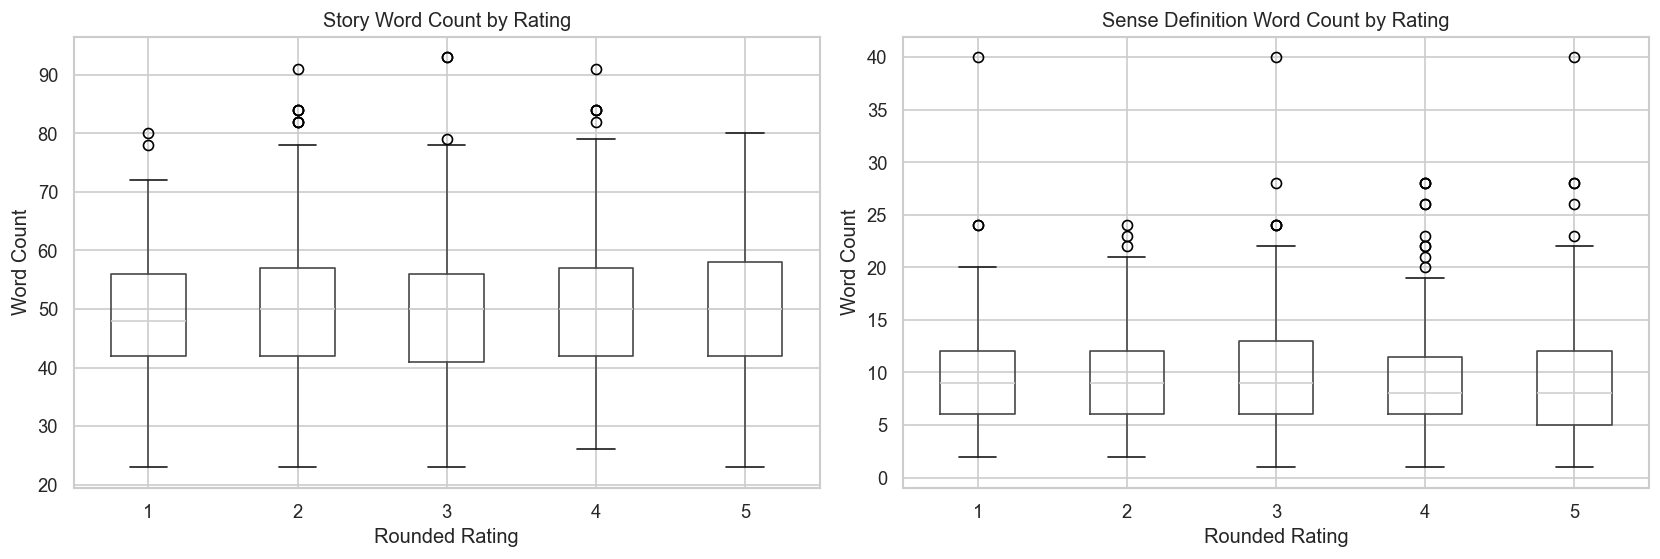

In [16]:
# Box plot: rating vs story length, meaning length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df.boxplot(column="story_word_count", by="rounded_rating", ax=axes[0])
axes[0].set_title("Story Word Count by Rating")
axes[0].set_xlabel("Rounded Rating")
axes[0].set_ylabel("Word Count")

train_df.boxplot(column="meaning_word_count", by="rounded_rating", ax=axes[1])
axes[1].set_title("Sense Definition Word Count by Rating")
axes[1].set_xlabel("Rounded Rating")
axes[1].set_ylabel("Word Count")

plt.suptitle("")
plt.tight_layout()
plt.show()

## 8. Nonsensical Annotations Analysis

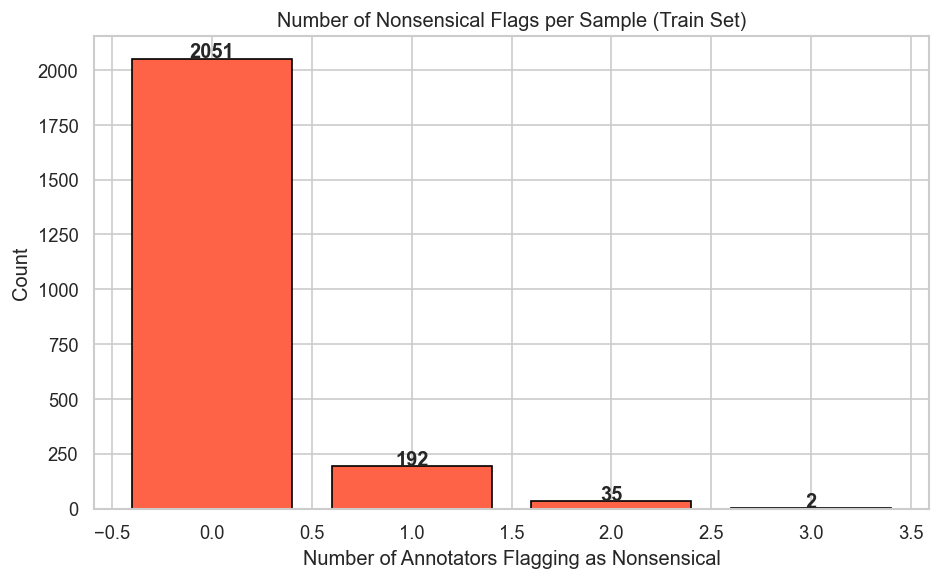

Samples with at least 1 nonsensical flag: 229 (10.0%)

Mean rating (nonsensical flagged):     2.645
Mean rating (no nonsensical flags):     3.195


In [17]:
# Nonsensical flags — how many annotators flagged each entry as nonsensical?
train_df["nonsensical_count"] = train_df["nonsensical"].apply(lambda x: sum(x))

fig, ax = plt.subplots(figsize=(8, 5))
ns_counts = train_df["nonsensical_count"].value_counts().sort_index()
ax.bar(ns_counts.index, ns_counts.values, color="tomato", edgecolor="black")
ax.set_title("Number of Nonsensical Flags per Sample (Train Set)")
ax.set_xlabel("Number of Annotators Flagging as Nonsensical")
ax.set_ylabel("Count")
for i, v in zip(ns_counts.index, ns_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Samples with at least 1 nonsensical flag: {(train_df['nonsensical_count'] > 0).sum()} "
      f"({(train_df['nonsensical_count'] > 0).mean()*100:.1f}%)")

# Average rating for nonsensical vs non-nonsensical
ns_mask = train_df["nonsensical_count"] > 0
print(f"\nMean rating (nonsensical flagged):     {train_df.loc[ns_mask, 'average'].mean():.3f}")
print(f"Mean rating (no nonsensical flags):     {train_df.loc[~ns_mask, 'average'].mean():.3f}")

## 9. Individual Annotator Rating Distribution

Number of annotators per sample:
choices
5    2246
6      34
Name: count, dtype: int64



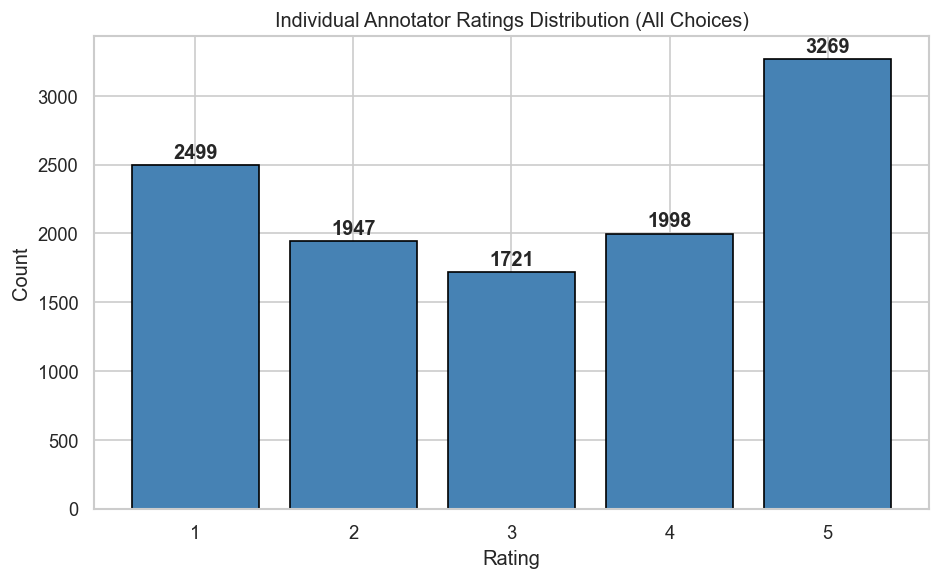

In [18]:
# Distribution of individual annotator ratings (from choices lists)
all_choices = [c for choices in train_df["choices"] for c in choices]
num_annotators = train_df["choices"].apply(len).value_counts()
print(f"Number of annotators per sample:\n{num_annotators}\n")

fig, ax = plt.subplots(figsize=(8, 5))
choice_counts = Counter(all_choices)
ratings = sorted(choice_counts.keys())
counts = [choice_counts[r] for r in ratings]
ax.bar(ratings, counts, color="steelblue", edgecolor="black")
ax.set_title("Individual Annotator Ratings Distribution (All Choices)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_xticks([1, 2, 3, 4, 5])
for r, c in zip(ratings, counts):
    ax.text(r, c + 50, str(c), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Train vs Validation Distribution Comparison

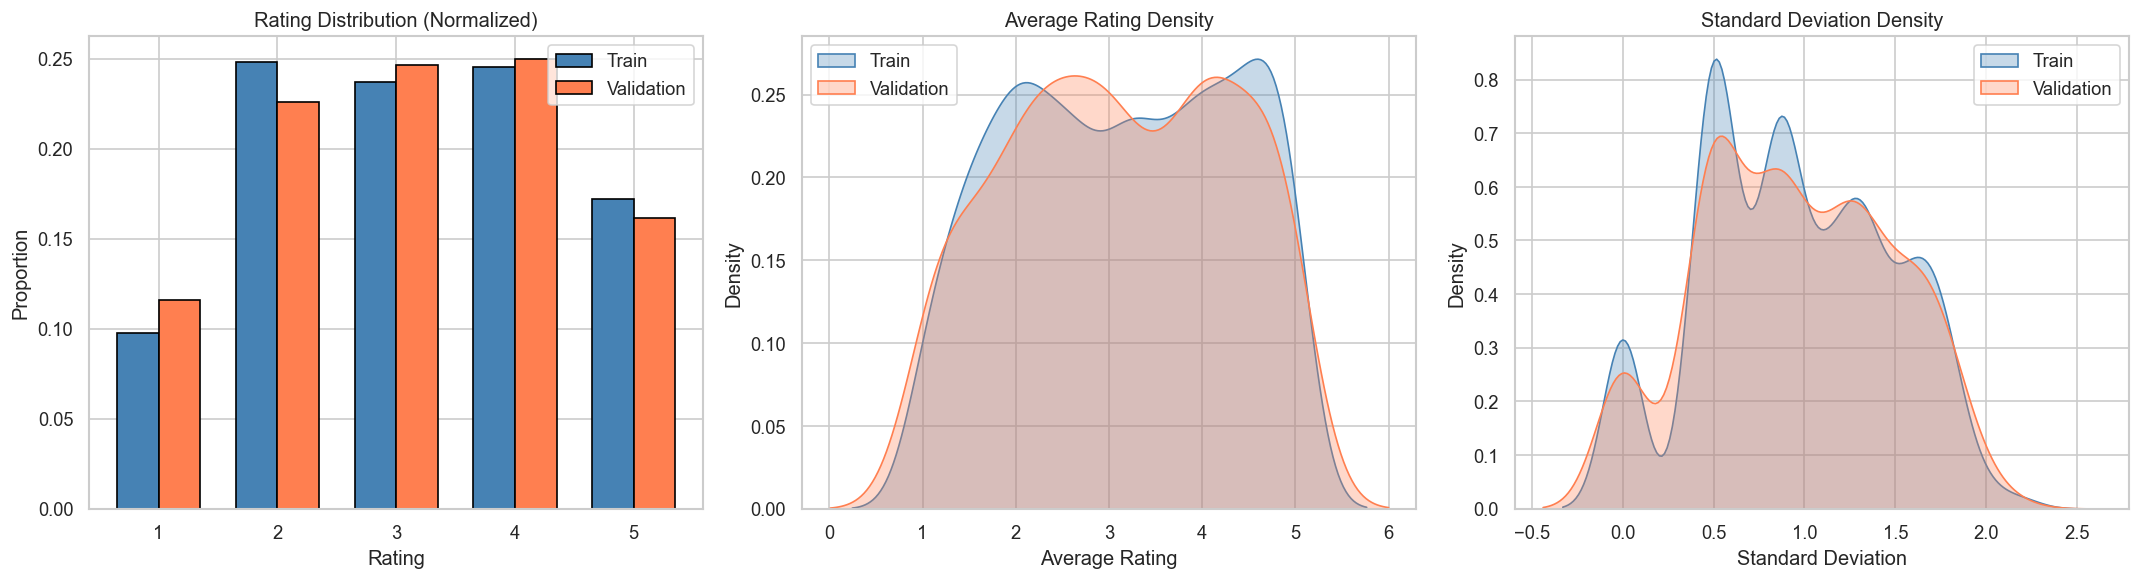

KS test (avg rating) — stat: 0.0235, p-value: 0.9526
→ Distributions are similar


In [19]:
# Compare train vs validation distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution comparison (normalized)
train_norm = train_df["rounded_rating"].value_counts(normalize=True).sort_index()
val_norm = val_df["rounded_rating"].value_counts(normalize=True).sort_index()

x = np.arange(1, 6)
width = 0.35
axes[0].bar(x - width/2, [train_norm.get(i, 0) for i in x], width, label="Train", color="steelblue", edgecolor="black")
axes[0].bar(x + width/2, [val_norm.get(i, 0) for i in x], width, label="Validation", color="coral", edgecolor="black")
axes[0].set_title("Rating Distribution (Normalized)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Proportion")
axes[0].set_xticks(x)
axes[0].legend()

# Average rating KDE
axes[1].set_title("Average Rating Density")
sns.kdeplot(train_df["average"], ax=axes[1], label="Train", color="steelblue", fill=True, alpha=0.3)
sns.kdeplot(val_df["average"], ax=axes[1], label="Validation", color="coral", fill=True, alpha=0.3)
axes[1].set_xlabel("Average Rating")
axes[1].legend()

# Stdev KDE
axes[2].set_title("Standard Deviation Density")
sns.kdeplot(train_df["stdev"], ax=axes[2], label="Train", color="steelblue", fill=True, alpha=0.3)
sns.kdeplot(val_df["stdev"], ax=axes[2], label="Validation", color="coral", fill=True, alpha=0.3)
axes[2].set_xlabel("Standard Deviation")
axes[2].legend()

plt.tight_layout()
plt.show()

# KS test to check if distributions are similar
ks_stat, ks_pval = stats.ks_2samp(train_df["average"], val_df["average"])
print(f"KS test (avg rating) — stat: {ks_stat:.4f}, p-value: {ks_pval:.4f}")
print("→ Distributions are " + ("similar" if ks_pval > 0.05 else "significantly different"))

## 11. Correlation Heatmap

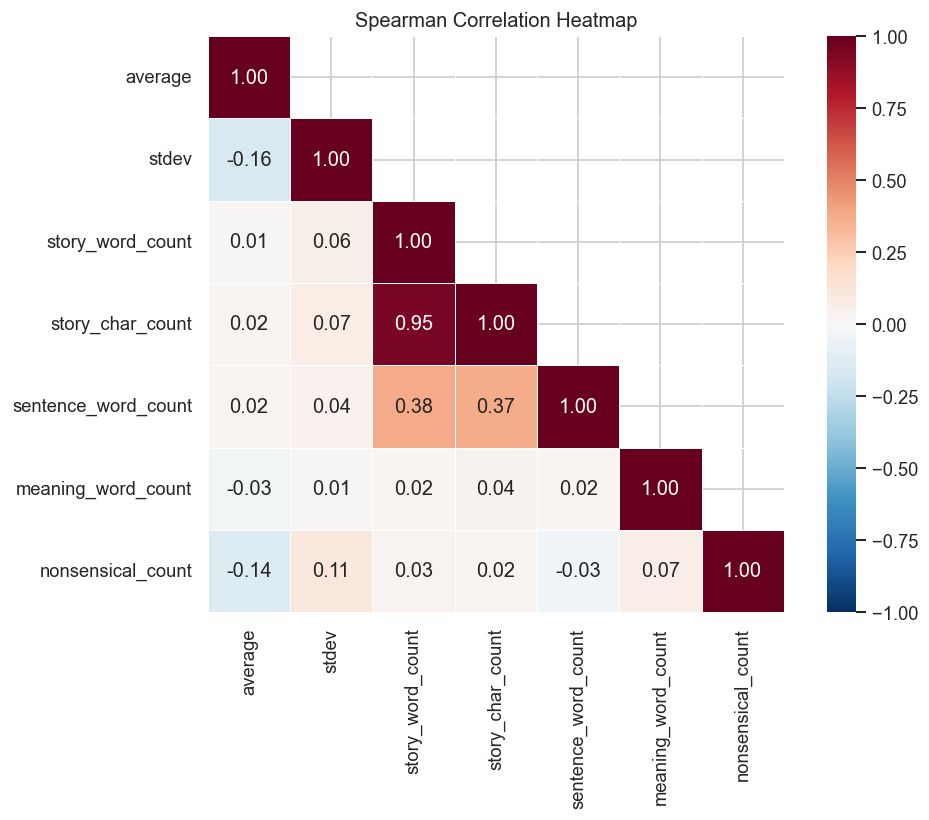

In [20]:
# Correlation heatmap of numerical features
numeric_cols = ["average", "stdev", "story_word_count", "story_char_count", 
                "sentence_word_count", "meaning_word_count", "nonsensical_count"]
corr_matrix = train_df[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. Summary Statistics

In [21]:
# Summary table
summary = pd.DataFrame({
    "Metric": [
        "Total samples (train)",
        "Total samples (validation)",
        "Unique homonyms (train)",
        "Unique homonyms (validation)",
        "Annotators per sample",
        "Mean plausibility rating (train)",
        "Median plausibility rating (train)",
        "Mean stdev (train)",
        "Mean story word count",
        "Mean sense definition word count",
        "Samples with nonsensical flags (train)",
        "Paired sense entries (train)",
    ],
    "Value": [
        len(train_df),
        len(val_df),
        train_df["homonym"].nunique(),
        val_df["homonym"].nunique(),
        train_df["choices"].apply(len).mode().iloc[0],
        f"{train_df['average'].mean():.3f}",
        f"{train_df['average'].median():.3f}",
        f"{train_df['stdev'].mean():.3f}",
        f"{train_df['story_word_count'].mean():.1f}",
        f"{train_df['meaning_word_count'].mean():.1f}",
        f"{(train_df['nonsensical_count'] > 0).sum()} ({(train_df['nonsensical_count'] > 0).mean()*100:.1f}%)",
        len(paired_df),
    ]
})
summary

,Metric,Value
0,Total samples (train),2280
1,Total samples (validation),588
2,Unique homonyms (train),220
3,Unique homonyms (validation),55
4,Annotators per sample,5
5,Mean plausibility rating (train),3.140
6,Median plausibility rating (train),3.200
7,Mean stdev (train),0.948
8,Mean story word count,50.0
9,Mean sense definition word count,9.3
